In [7]:
# import packages
import os
import numpy as np
import netCDF4 as nc
import datetime as dt
import sys
from glob import glob
import matplotlib.pyplot as plt
import calendar
import numpy.ma as ma
import string
import matplotlib.cm as cmap
from scipy import integrate
from scipy import interpolate
from scipy import stats
from matplotlib.ticker import NullFormatter
import scipy
from scipy import signal
import xarray as xr
from tqdm import tqdm

from beam_model import beam_model_calc,eval_es,eval_theta_e,eval_q,eval_qs

In [ ]:
# user_specified
pr_thresh=.5 # threshold for raining events

In [8]:
# constants
rd = 287.04 # gas constant of dry air
rv = 461.50 # gas constant of water vapor
cvd = 719. # heat capacity at constant volume for dry air
cpd = 1005.7 # heat capacity at constant pressure for dry air
cvv = 1410. # heat capacity at constant volume of water vapor
cpv = 1870. # heat capacity at constant pressure of water vapor
cl = 4190. # heat capacity of liquid water (above freezing)
cpi = 2093.
cpvmcl = cl-cpv # cpvmcl seems to be a common notation for this value

# Units: dimensionless
epsilon = rd/rv

# Units: J/Kg
lv0 = 2.501E6 # latent heat of vaporization at 0-deg-C
ls = 2.834E6 # latent heat of sublimation (-100<=T<= 0-deg-C)
lf = 0.3337E6 # latent heat of fusion at 0-deg-C (lv0-ls)

# Units: m/s**2
g = 9.80665 # standard gravity

In [ ]:
# ---------------------------------------------------------
# READ NETCDF
# ---------------------------------------------------------

arm_nc = 'processed_ARMBE_manus_nauru_theta_e_and_condensate.nc'

arm_nc = nc.Dataset(arm_nc, 'r')
time = arm_nc.variables['time'][:]
lev = arm_nc.variables['lev'][:]
theta_es_lft = arm_nc.variables['theta_es_lft'][:]
theta_e_lft  = arm_nc.variables['theta_e_lft'][:]
ta_lft       = arm_nc.variables['ta_lft'][:]
theta_e_bl = arm_nc.variables['theta_e_bl'][:]
q_bl       = arm_nc.variables['q_bl'][:]
q_lft      = arm_nc.variables['q_lft'][:]
qs_lft     = arm_nc.variables['qs_lft'][:]
pr = arm_nc.variables['pr'][:]

rh_full = arm_nc.variables['rh_full'][:]

theta_e  = arm_nc.variables['theta_e'][:]
theta_es = arm_nc.variables['theta_es'][:]

lwc      = arm_nc.variables['lwc'][:]
lwc_mwrp = arm_nc.variables['lwc_mwrp'][:]
ice      = arm_nc.variables['ice'][:]

q       = arm_nc.variables['q'][:]
qs_full = arm_nc.variables['qs_full'][:]

ta_full = arm_nc.variables['ta_full'][:]
es_full = arm_nc.variables['es_full'][:]

tv  = arm_nc.variables['tv'][:]
rho = arm_nc.variables['rho'][:]

lwc_gkg = arm_nc.variables['lwc_gkg'][:]
iwc_gkg = arm_nc.variables['iwc_gkg'][:]

qc_env = arm_nc.variables['qc_env'][:]
arm_nc.close()

In [12]:
# Find events and durations. Events with precip in preceeding 6 hours are not included

in_event = pr>=pr_thresh # find raining times
ev = in_event
beg_inds = np.zeros(ev.shape,dtype=bool) # initialize beginning of event indices
beg_lag = -6 # if precip 6 hours before, don't include event
rainfree = np.zeros(ev.shape,dtype=bool)
for ii in np.arange(1-beg_lag,len(pr)-1):
    beg_inds[ii] = np.logical_and(np.logical_and(ev[ii],~ev[ii-1]),np.sum(ev[ii+beg_lag:ii],axis=0)<1)
    rainfree[ii] = np.sum(ev[ii+beg_lag:ii],axis=0)<1

beg_num = np.argwhere(beg_inds).squeeze()
print(str(len(beg_num)) + ' events found')

# calculate duration of events
duration = np.zeros(len(beg_num),dtype=int)
for i in np.arange(len(beg_num)):
    dur_count = 1
    raining = True
    while raining:
        if (beg_num[i] + dur_count >= len(pr)):
            raining = False
        elif pr[beg_num[i] + dur_count]>.5:
            dur_count = dur_count + 1
        else:
            raining = False
    duration[i] = dur_count
    
mature = np.logical_and(pr>=pr_thresh,~beg_inds)
levh = lev/100

4542 events


In [374]:
nonan_beg = (~np.isnan(theta_es[beg_inds,20])) # check random level in profs to see if nan values

In [375]:
frz_const = False # True: use condensate at freezing level; False: use max condensate value in the column
qmin = 0 # minimum condensate for defining deep convecetive onset
frz_ta = np.logical_and(ta_full<T0+3,ta_full>T0-3) # freezing layer defined +- 3 K
qc_freeze_peak = np.nanmax(np.where(frz_ta, qc_env, np.nan), axis=1) # qc in freezing layer
deep_onset = qc_freeze_peak > qmin # deep onset times
deep_beg_inds = np.logical_and(deep_onset,beg_inds) # initalize indices of deep onset and beginning of event
# compute quantiles and percentiles
if frz_const:
    qc_deep_beg = qc_freeze_peak[np.logical_and(deep_onset,beg_inds)]
    q10, q50, q90 = np.nanquantile(qc_deep_beg, [0.10, 0.50, 0.9])
    qc90 = np.nanpercentile(qc_env[deep_beg_inds],90,axis=0)
    qc10 = np.nanpercentile(qc_env[deep_beg_inds],10,axis=0)
    qc50 = np.nanpercentile(qc_env[deep_beg_inds],50,axis=0)
else:
    qc_peak = np.nanmax(qc_env, axis=1)
    qc_deep_beg = qc_peak[beg_inds]#[np.logical_and(deep_onset,beg_inds)]
    q25, q50, q75 = np.nanquantile(qc_deep_beg, [0.25, 0.50, 0.75])
    qc90 = np.nanpercentile(qc_env[deep_beg_inds],90,axis=0)
    qc75 = np.nanpercentile(qc_env[deep_beg_inds],75,axis=0)
    qc25 = np.nanpercentile(qc_env[deep_beg_inds],25,axis=0)
    qc50 = np.nanpercentile(qc_env[deep_beg_inds],50,axis=0)
    qc10 = np.nanpercentile(qc_env[deep_beg_inds],10,axis=0)
    qc50 = np.nanpercentile(qc_env[deep_beg_inds],50,axis=0)
    qcavg = np.nanmean(qc_env[deep_beg_inds],axis=0)

qavg = np.nanmean(qc_deep_beg) # Mean condensate constraint value



/tmp/ipykernel_244198/2217353712.py:4: RuntimeWarning: All-NaN slice encountered
  qc_freeze_peak = np.nanmax(np.where(frz_ta, qc_env, np.nan), axis=1)
/tmp/ipykernel_244198/2217353712.py:14: RuntimeWarning: All-NaN slice encountered
  qc_peak = np.nanmax(qc_env, axis=1)


In [376]:
# Calculate quantities for buoyancy calculation
l_eff_full = lam(ta_full)*ls(ta_full) + (1-lam(ta_full))*lv(ta_full) # effective latent heat
kap_full         = 1+l_eff_full**2*qs_full/cpd/rv/ta_full/T0 # effective kappa 
scl_rho = theta_es*kap_full # fractional theta_es difference scaling
es_rho = theta_es*(1 + kap_full*0.61*q) # density equivalent potential temperature

In [377]:
# interpolate ARM data to 5 hPa steps for model with cubic spline
from scipy.interpolate import interp1d, CubicSpline
levs = np.arange(1000e2,200e2,-500)
levh = levs/100

lev_inc = np.flipud(lev)
scl_rho_beg = np.nanmean(scl_rho[beg_inds],axis=0)
es_rho_beg = np.nanmean(es_rho[beg_inds],axis=0)

es_beg = np.nanmean(theta_es[beg_inds],axis=0)
e_beg = np.nanmean(theta_e[beg_inds],axis=0)
q_beg = np.nanmean(q[beg_inds],axis=0)
ta_beg = np.nanmean(ta_full[beg_inds],axis=0)

f_es_rho = CubicSpline(lev_inc,np.flipud(es_rho_beg))
f_scl_rho = CubicSpline(lev_inc,np.flipud(scl_rho_beg))

f_es = CubicSpline(lev_inc,np.flipud(es_beg))
f_e = CubicSpline(lev_inc,np.flipud(e_beg))
f_q = CubicSpline(lev_inc,np.flipud(q_beg))
f_ta = CubicSpline(lev_inc,np.flipud(ta_beg))



f_lwc = interp1d(lev,lwc_gkg , axis=1, bounds_error=False, fill_value="extrapolate")
f_iwc = interp1d(lev,iwc_gkg , axis=1, bounds_error=False, fill_value="extrapolate")
f_ta_all = interp1d(lev,ta_full, axis=1, bounds_error=False, fill_value="extrapolate")

es_rho_ref = f_es_rho(levs)
scl_rho_ref = f_scl_rho(levs)
es_ref = f_es(levs)
e_ref = f_e(levs)
q_ref = f_q(levs)
ta_ref = f_ta(levs)
lwc_interp = f_lwc(levs)  
iwc_interp = f_iwc(levs) 
ta_interp = f_ta_all(levs)


qs_ref = eval_qs(ta_ref,levs)
l_eff = lam(ta_ref)*ls(ta_ref) + (1-lam(ta_ref))*lv(ta_ref)
kap          = 1+l_eff**2*qs_ref/cpd/rv/ta_ref/T0


In [378]:
# Set up mixing coefficients for the model
e_hat = 1 # epsilon hat, factor multitplying '1/z' entrainment
pb = 900e2
pl = 600e2
lft = np.logical_and(levs<pb,levs>=pl)

c_mix = 1/(levs - levs[0])
c_mix[0] = 0
c_mix[levh<=600] = 0

c_nomix = np.copy(c_mix)
c_nomix[levs<=pb] = 0
c_mix[levs<=pb] = c_mix[levs<=pb]*e_hat

/tmp/ipykernel_244198/3597769192.py:8: RuntimeWarning: divide by zero encountered in divide
  c_mix = 1/(levs - levs[0])


159it [00:00, 868.97it/s]
159it [00:00, 877.46it/s]
159it [00:00, 885.78it/s]
159it [00:00, 889.66it/s]
159it [00:00, 995.68it/s] 
159it [00:00, 994.06it/s] 


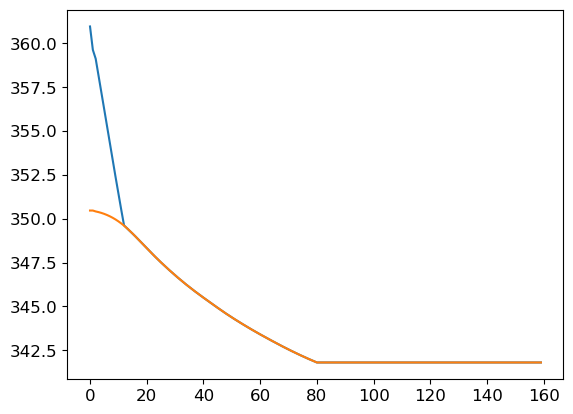

In [379]:
gam = [0,.5,1]#np.arange(1,-.2,-.2)

ep = np.zeros((len(gam),len(levs)))
epn = np.zeros_like(gam)
epb = np.zeros((len(gam),len(levs)))
epnb = np.zeros_like(epb)
tp = np.zeros((len(gam),len(levs)))
tpn = np.zeros((len(gam),len(levs)))
qc = np.zeros((len(gam),len(levs)))
qcn = np.zeros((len(gam),len(levs)))

s = np.zeros((len(gam),len(levs)))
sn = np.zeros((len(gam),len(levs)))

cpl = np.zeros((len(gam),len(levs)))
cpln = np.zeros((len(gam),len(levs)))

for a,i in enumerate(gam):
    # run model for mixing and nonmixing cases 
    # mixing
    ep[a],tp[a],qv,ql,qi = beam_model_calc(ta_ref[0],levs,q_ref[0],ta_ref,q_ref,c_mix,loss_type='fractional',gam=i)
    #  nonmixing
    epn[a],tpn[a],qvn,qln,qin = beam_model_calc(ta_ref[0],levs,q_ref[0],ta_ref,q_ref,c_nomix,loss_type='fractional',gam=i)
    # compute saturation entropy, s_sat
    qt = qv+ql+qi
    cpl[a] = cpd + (cl-cpd)*qt
    s_sat = comp_s(tp[a],levs,eval_qs(tp[a],levs,qt),ql,qi)

    qtn = qvn+qln+qin
    cpln[a] = cpd + (cl-cpd)*qtn
    s_satn = comp_s(tpn[a],levs,eval_qs(tpn[a],levs,qtn),qln,qin)
    
    # density theta_e
    es_p = T0*np.exp(s_sat/cpl[a])
    es_pn = T0*np.exp(s_satn/cpln[a])

    s[a] = s_sat
    sn[a] = s_satn
    
    qc[a] = ql + qi
    qcn[a] = qln + qin
    epb[a] = es_p + scl_rho_ref*(0.61*(qv) - ql - qi)
    epnb[a] = es_pn + scl_rho_ref*(0.61*(qvn) - qln- qin)

# s of env
s_env = comp_s(ta_ref,levs,qs_ref,0,0)


/tmp/ipykernel_244198/3297505743.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


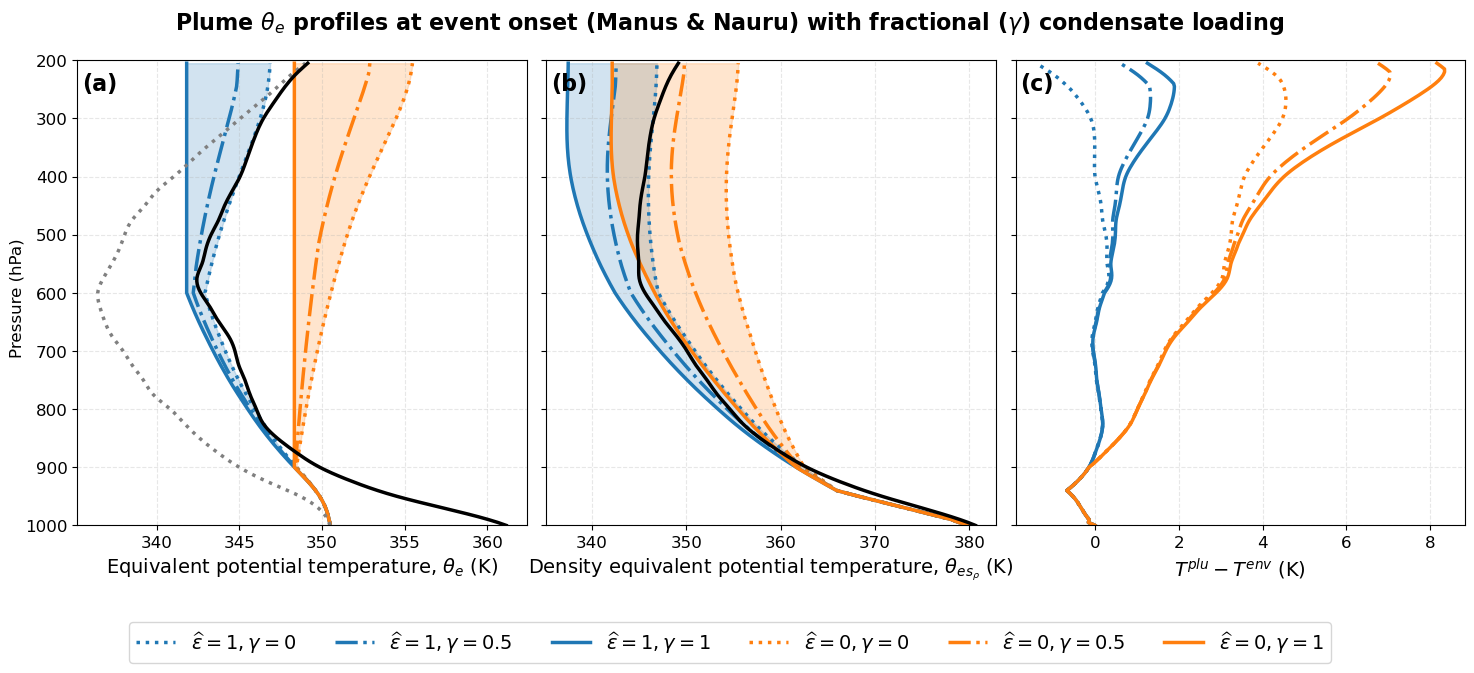

In [388]:
# plot 2 cases: Figure 1 in Emmenegger et al. 2026

from matplotlib.lines import Line2D
levh = levs/100
color_cycle = plt.rcParams['axes.prop_cycle']
colors = color_cycle.by_key()['color']
lss = [':','-.','-']
lws = 2.5
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})
fig,ax = plt.subplots(1,3,figsize=(15,6))
for a,i in enumerate(acc):
    # plt.plot(ep,levh,label=str(np.round(i,1)),color=colors[a])
    ax[0].plot(ep[a] ,levh,label=r'$\widehat{\epsilon} = 1, \gamma =$' + str(np.round(i,1)),color='tab:blue',ls=lss[a],lw=lws)
    ax[0].plot(epn[a],levh,label= r'$\widehat{\epsilon} = 0, \gamma =$' + str(np.round(i,1)),color='tab:orange',ls=lss[a],lw=lws)
    ax[1].plot(epb[a] ,levh,label=r'$\widehat{\epsilon} = 1, \gamma =$' + str(np.round(i,1)),color='tab:blue',ls=lss[a],lw=lws)
    ax[1].plot(epnb[a],levh,label= r'$\widehat{\epsilon} = 0, \gamma =$' + str(np.round(i,1)),color='tab:orange',ls=lss[a],lw=lws)
    ax[2].plot(tp[a]- ta_ref,levh,color='tab:blue',ls=lss[a],lw=lws)
    ax[2].plot(tpn[a]- ta_ref,levh,color='tab:orange',ls=lss[a],lw=lws)

# ax[2].plot(qc[1]*1e3,levh,color='tab:blue',ls=lss[1],lw=lws)
# ax[2].plot(qcn[1]*1e3,levh,color='tab:orange',ls=lss[1],lw=lws)

# ep,tp,qv,ql,qi = inv_model_mix(ta_ref[0],levs,q_ref[0],ta_ref,q_ref,c_mix,loss_type='decay',ac=.2)
# plt.plot(ep,levh,label=r'$\gamma(T;\alpha_c = 0.2)$',color=colors[a+1])
# ax[1].plot(es_ref + kap*es_ref*0.61*q_ref,levh,color='black',lw=lws,label=r'$\theta_{es}$')
ax[1].plot(es_rho_ref,levh,color='black',lw=lws,label=r'$\theta_{es}$')

ax[0].plot(e_ref,levh,color='gray',ls=':',lw=lws,label=r'$\theta_{e}$')
ax[0].plot(es_ref,levh,color='black',lw=lws,label=r'$\theta_{es}$')
# ax[2].plot(s_env,levh,color='black',lw=lws)
# ax[1].plot(ta_ref-tpn[0],levh,color='black',lw=lws)
handles, labels = ax[0].get_legend_handles_labels()
order = [0,2,4,1,3,5]
fig.legend([handles[idx] for idx in order],[labels[idx] for idx in order],ncol=6,loc="upper center",
    bbox_to_anchor=(0.5, -0.025),fontsize=14)
ax[0].set_ylim(1000,200)
ax[1].set_ylim(1000,200)
ax[2].set_ylim(1000,200)
ax[0].set_xlabel(r'Equivalent potential temperature, $\theta_e$ (K)')
ax[1].set_xlabel(r'Density equivalent potential temperature, $\theta_{es_\rho}$ (K)')
ax[2].set_xlabel(r'$T^{plu} - T^{env}$ (K)')


ax[1].fill_betweenx(levh,epb[-1],epb[0],color='tab:blue',alpha=.2,zorder=0)
ax[1].fill_betweenx(levh,epnb[-1],epnb[0],color='tab:orange',alpha=.2,zorder=0)

ax[0].fill_betweenx(levh,ep[-1],ep[0],color='tab:blue',alpha=.2,zorder=0)
ax[0].fill_betweenx(levh,epn[-1],epn[0],color='tab:orange',alpha=.2,zorder=0)
ax[1].set_yticklabels([])
ax[2].set_yticklabels([])

# ax[2].fill_betweenx(levh,qc_lo,qc_hi,color='black',alpha=.2,zorder=0)

ax[0].grid(True, linestyle="--", alpha=0.3)
ax[1].grid(True, linestyle="--", alpha=0.3)
ax[2].grid(True, linestyle="--", alpha=0.3)
# ax.legend(frameon=True, framealpha=0.85,title=r'$\theta_e^{plu}$')


labels = ['(a)', '(b)', '(c)']

for axi, lab in zip(ax.flat, labels):
    axi.text(
        0.01, 0.975, lab,                 # position (x,y) in axes coords
        transform=axi.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top', ha='left'
    )

plt.tight_layout()

fig.supylabel(r'Pressure (hPa)')
fig.suptitle(r'Plume $\theta_e$ profiles at event onset (Manus & Nauru) with fractional ($\gamma$) condensate loading',fontweight='bold',fontsize=16)
plt.tight_layout()
plt.savefig("beam_fracCond.pdf")


In [389]:
# Set up mixing coefficients for the model
e_hat = 1
pb = 900e2
pl = 600e2
lft = np.logical_and(levs<pb,levs>=pl)


c_mix = 1/(levs - levs[0])
c_mix[0] = 0
c_mix[levh<=600] = 0
c_mix[levs<=pb] = c_mix[levs<=pb]*e_hat

/tmp/ipykernel_244198/563993226.py:8: RuntimeWarning: divide by zero encountered in divide
  c_mix = 1/(levs - levs[0])


In [390]:
# As above, but for the condensate decay function
gam = [1,.8,.6,.4,.2,0]

ep = np.zeros((len(gam),len(levs)))
epn = np.zeros_like(ep)
epb = np.zeros((len(gam),len(levs)))
epnb = np.zeros_like(epb)
tp = np.zeros((len(gam),len(levs)))
tpn = np.zeros((len(gam),len(levs)))
qc = np.zeros((len(gam),len(levs)))
qcn = np.zeros((len(gam),len(levs)))

s = np.zeros((len(gam),len(levs)))
sn = np.zeros((len(gam),len(levs)))

cpl = np.zeros((len(gam),len(levs)))
cpln = np.zeros((len(gam),len(levs)))

for a,i in enumerate(gam):
    loss_f = 'decay'
    if i<.001:
        loss_f = 'fractional'
    print(loss_f)
    ep[a],tp[a],qv,ql,qi = inv_model_mix(ta_ref[0],levs,q_ref[0],ta_ref,q_ref,c_mix,loss_type=loss_f,gam=i,beta = np.log(10e3)/40)
    epn[a],tpn[a],qvn,qln,qin = inv_model_mix(ta_ref[0],levs,q_ref[0],ta_ref,q_ref,c_nomix,loss_type=loss_f,gam=i,beta = np.log(10e3)/40)

    qt = qv+ql+qi
    cpl[a] = cpd + (cl-cpd)*qt
    s_sat = comp_s(tp[a],levs,eval_qs(tp[a],levs,qt),ql,qi)

    qtn = qvn+qln+qin
    cpln[a] = cpd + (cl-cpd)*qtn
    s_satn = comp_s(tpn[a],levs,eval_qs(tpn[a],levs,qtn),qln,qin)
    
    
    es_p = T0*np.exp(s_sat/cpl[a])
    es_pn = T0*np.exp(s_satn/cpln[a])

    s[a] = s_sat
    sn[a] = s_satn
    
    qc[a] = ql + qi
    qcn[a] = qln + qin
    epb[a] = es_p + scl_rho_ref*(0.61*(qv) - ql - qi)
    epnb[a] = es_pn + scl_rho_ref*(0.61*(qvn) - qln- qin)

s_env = comp_s(ta_ref,levs,qs_ref,0,0)

decay


159it [00:00, 978.62it/s] 
159it [00:00, 978.09it/s] 


decay


159it [00:00, 984.29it/s] 
159it [00:00, 990.04it/s] 


decay


...

159it [00:00, 985.25it/s] 
159it [00:00, 984.45it/s] 


decay


159it [00:00, 977.26it/s] 
159it [00:00, 986.34it/s] 


fractional


159it [00:00, 873.61it/s]
159it [00:00, 873.15it/s]


/tmp/ipykernel_244198/3498024943.py:93: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


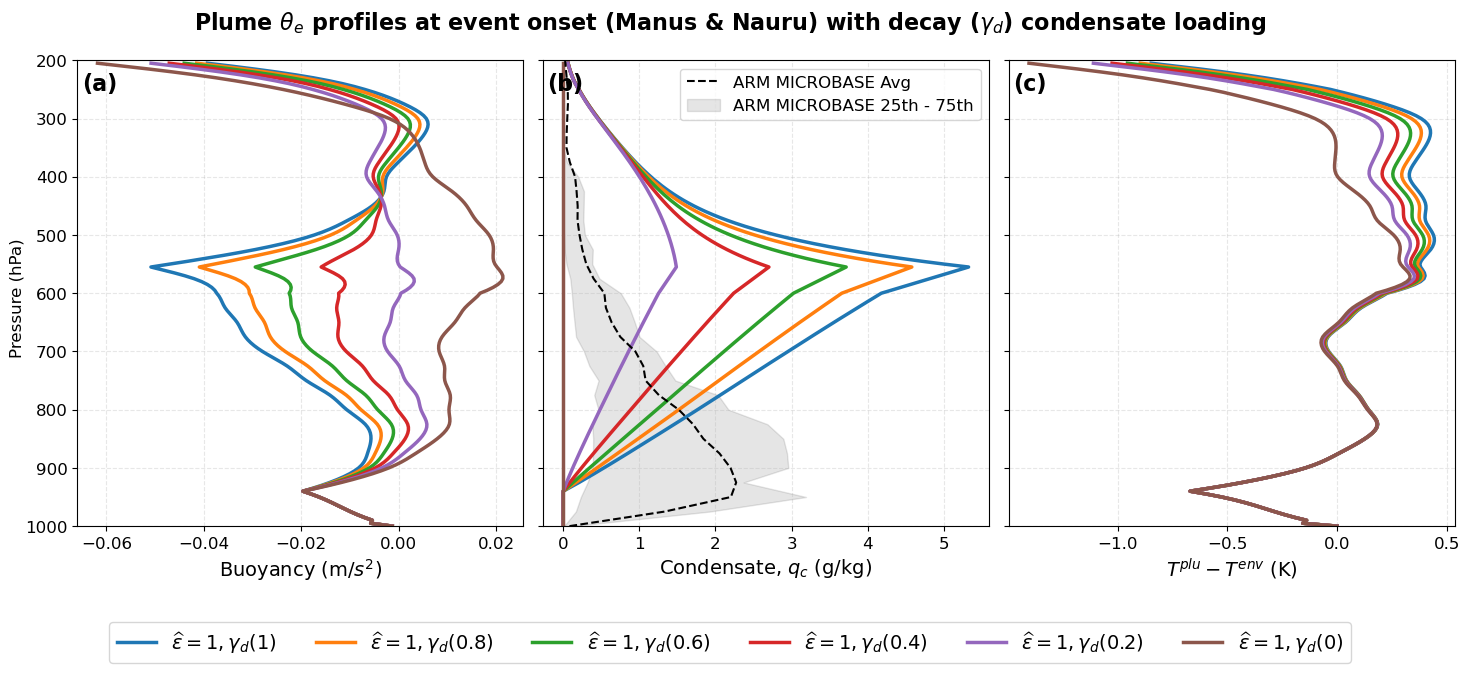

In [392]:
# Figure 2 in Emmenegger et al. 2026
from matplotlib.lines import Line2D
levh = levs/100
color_cycle = plt.rcParams['axes.prop_cycle']
colors = color_cycle.by_key()['color']
lws = 2.5
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

# es_terms = es_ref + kap*es_ref*0.61*q_ref
bn = g*(epnb - es_rho_ref)/scl_rho_ref
b = g*(epb - es_rho_ref)/scl_rho_ref

fig,ax = plt.subplots(1,3,figsize=(15,6))
for a,i in enumerate(acc):
    ax[0].plot(b[a] ,levh,label=r'$\widehat{\epsilon} = 1, \gamma_d($' + str(np.round(i,1))+ ')',color=colors[a],lw=lws)
    ax[1].plot(qc[a]*1000,levh,lw=lws)
    ax[2].plot(tp[a]- ta_ref,levh,color=colors[a],lw=lws)

ax[0].set_ylim(1000,200)
ax[1].set_ylim(1000,200)
ax[2].set_ylim(1000,200)

ax[0].set_xlabel(r'Buoyancy (m/$s^2$)')
ax[1].set_xlabel(r'Condensate, $q_c$ (g/kg)')
ax[2].set_xlabel(r'$T^{plu} - T^{env}$ (K)')



ax[2].set_yticklabels([])
ax[1].set_yticklabels([])
# ax[1].fill_betweenx(lev/100,qc10,qc90,color='black',alpha=.1,zorder=0,label='ARM MICROBASE 10th - 90th')
ax[1].plot(qcavg,lev/100,color='black',ls='--',label='ARM MICROBASE Avg')
ax[1].fill_betweenx(lev/100,qc25,qc75,color='black',alpha=.1,zorder=0,label='ARM MICROBASE 25th - 75th')
# ax[1].plot(q50,lev/100,color='black',ls='--',label='ARM MICROBASE 50th')

# T_bnds = np.logical_and(ta_ref<T0-3

# ax[1].fill_between(lev/100, y1, y2, hatch='///', color='black', alpha=0.1)



ax[0].grid(True, linestyle="--", alpha=0.3)
ax[1].grid(True, linestyle="--", alpha=0.3)
ax[2].grid(True, linestyle="--", alpha=0.3)


labels = ['(a)', '(b)', '(c)']

for axi, lab in zip(ax.flat, labels):
    axi.text(
        0.01, 0.975, lab,                 
        transform=axi.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top', ha='left'
    )

handles, labels = ax[0].get_legend_handles_labels()
order = [0,2,4,1,3,5]
fig.legend(handles,labels,ncol=len(acc),loc="upper center",
    bbox_to_anchor=(0.5, -0.025),fontsize=14)

T_star = T0  # your freezing reference (273.16 K)
freeze_mask = (ta_beg >= (T0 - 3.0)) & (ta_beg <= (T0 + 3.0))  # shape (lev,)

p_hpa = lev/100


plt.tight_layout()

fig.supylabel(r'Pressure (hPa)')
fig.suptitle(r'Plume $\theta_e$ profiles at event onset (Manus & Nauru) with decay ($\gamma_d$) condensate loading',fontweight='bold',fontsize=16)
ax[1].legend()

plt.tight_layout()
# plt.savefig("beam_fracCond.pdf")


In [348]:
# COSMIC-2 DATA for ref plots
cosmic_es_beg =np.array([359.90707, 356.54526, 352.2564 , 349.28848, 347.95316, 347.28687,
       346.89233, 346.69513, 346.52292, 346.27295, 345.901  , 345.44186,
       344.9322 , 344.41763, 343.89066, 343.42194, 343.06845, 342.89456,
       343.07956, 343.4317 , 343.88998, 344.35165, 344.79816, 345.23044,
       345.5959 , 345.8722 , 346.1636 , 346.5008 , 346.90298, 347.42145,
       348.06693, 348.9289 , 350.01672])
cosmic_es_dry = np.array([357.4735 , 354.68002, 350.48563, 347.54117, 346.3398 , 345.89352,
       345.77872, 345.86014, 345.94855, 345.90158, 345.6701 , 345.3104 ,
       344.8648 , 344.3704 , 343.87177, 343.42334, 343.09683, 342.94806,
       343.08575, 343.37466, 343.75198, 344.14944, 344.52393, 344.8697 ,
       345.17108, 345.38446, 345.60477, 345.89105, 346.27313, 346.79236,
       347.4939 , 348.45975, 349.72324])

In [352]:
# get model configurations
T_init = ta_ref[0]
qt = q_ref[0]
loss_type = 'decay'

In [354]:
# function to calculate buoyancy
pb = 900e2
pl = 600e2
mask_lft = (levs < pb) & (levs >= pl)   # levs in Pa
T_init = ta_ref[0]
qt_init = q_ref[0]
loss_type = 'decay'
c_mix0 = 1.0 / (levs - levs[0])
c_mix0[0] = 0.0
c_mix0[levs <= pl] = 0.0   

def BL_for(m_hat, gamma):
    c_mix = c_mix0.copy()
    c_mix[levs < pb] *= m_hat

    ep, tp, qv, ql, qi = inv_model_mix(
        T_init, levs, qt_init, ta_ref, q_ref, c_mix,
        loss_type=loss_type, gam=gamma
    )
    qt = qv+ql+qi
    cpl = cpd + (cl-cpd)*qt
    s_sat = comp_s(tp,levs,eval_qs(tp,levs,qt),ql,qi)
    
    
    es_p = T0*np.exp(s_sat/cpl)
    es_pb = es_p + scl_rho_ref*(0.61*qv - ql - qi)
    # b = g * ((es_p - es_ref)/kap/es_ref + 0.61*(qv - q_ref) - ql - qi)
    b = g*(es_pb - es_rho_ref)/scl_rho_ref
    # correct sign because levs decreases
    BL = -np.trapz(b[mask_lft], levs[mask_lft]) / (pb - pl)
    qc = ql + qi
    return BL, ep, es_pb, qv, qc, tp

# gamma_arr = np.linspace(1.0, 0.0, 50)
# m_hat = 0.0  # initial guess at gamma=1

gamma_arr = np.linspace(0, 1.0, 50)
m_hat = 1  # initial guess at gamma=1


m_hat_arr = np.full_like(gamma_arr, np.nan)
qv_arr = np.zeros((len(gamma_arr),len(levs)))
tp_arr = np.zeros((len(gamma_arr),len(levs)))

qc_arr = np.zeros((len(gamma_arr),len(levs)))
ep_arr = np.zeros((len(gamma_arr),len(levs)))
epb_arr = np.zeros((len(gamma_arr),len(levs)))

dm_hat = 1e-2
tol = 1e-3
max_newton = 20


/tmp/ipykernel_244198/3504901167.py:10: RuntimeWarning: divide by zero encountered in divide
  c_mix0 = 1.0 / (levs - levs[0])


In [355]:
from scipy.optimize import minimize_scalar

# loop through condensate retention parameter, gamma
for a, gamma in enumerate(tqdm(gamma_arr)):

    # define objective: minimize LFT buoyancy magnitude
    def objective(m_hat):
        BL, *_ = BL_for(m_hat, gamma)
        return BL**2   # minimize |BL|

    res = minimize_scalar(objective, bounds=(0.0, 10.0), method='bounded')
    # if objective fails, skip
    if not res.success:
        continue
    # save best fit
    m_hat = res.x

    # compute final solution at optimal m_hat
    BL0, ep, epb, qv, qc, tp = BL_for(m_hat, gamma)

    # store output
    m_hat_arr[a] = m_hat
    qv_arr[a] = qv
    qc_arr[a] = qc
    ep_arr[a] = ep
    epb_arr[a] = epb
    tp_arr[a] = tp

  0%|          | 0/50 [00:00<?, ?it/s]
0it [00:00, ?it/s]
159it [00:00, 836.56it/s][A

0it [00:00, ?it/s]
159it [00:00, 861.82it/s][A

0it [00:00, ?it/s]
159it [00:00, 839.16it/s][A

0it [00:00, ?it/s]
159it [00:00, 835.84it/s][A

0it [00:00, ?it/s]
159it [00:00, 840.86it/s][A

0it [00:00, ?it/s]
159it [00:00, 852.16it/s][A

0it [00:00, ?it/s]
159it [00:00, 843.88it/s][A

0it [00:00, ?it/s]
159it [00:00, 838.41it/s][A

0it [00:00, ?it/s]
159it [00:00, 815.42it/s][A

0it [00:00, ?it/s]
159it [00:00, 821.30it/s][A

0it [00:00, ?it/s]
159it [00:00, 832.19it/s][A

0it [00:00, ?it/s]
159it [00:00, 846.13it/s][A

0it [00:00, ?it/s]
159it [00:00, 844.58it/s][A

0it [00:00, ?it/s]
159it [00:00, 835.38it/s][A

0it [00:00, ?it/s]
159it [00:00, 837.70it/s][A
  2%|▏         | 1/50 [00:02<02:20,  2.88s/it]
0it [00:00, ?it/s]
159it [00:00, 891.74it/s][A

0it [00:00, ?it/s]
159it [00:00, 897.40it/s][A

0it [00:00, ?it/s]
159it [00:00, 890.60it/s][A

0it [00:00, ?it/s]
159it [00:00, 897.69it/s][A

0it

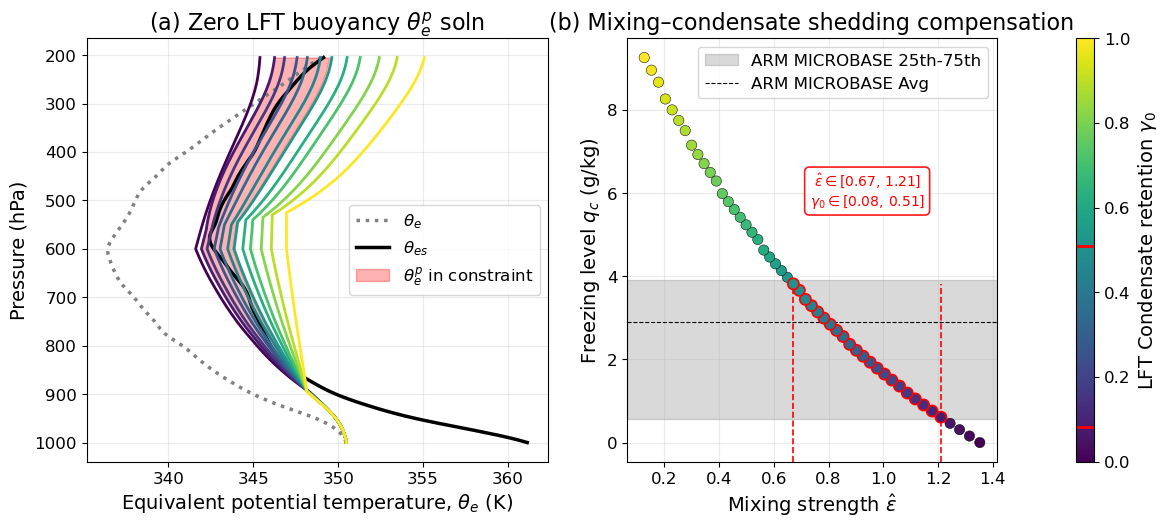

In [359]:
# Figure 3 in Emmenegger et al. 2026

fig = plt.figure(figsize=(13, 5.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.25, 1.0, 0.05], wspace=0.28)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])


ax0.plot(e_ref,levh,color='gray',ls=':',lw=lws,label=r'$\theta_{e}$')
ax0.plot(es_ref,levh,color='black',lw=lws,label=r'$\theta_{es}$')
# (a) theta_e profiles (subset), colored by gamma
for i in inds:
    ax0.plot(ep_arr[i], levs/100, color=cmap(norm(gamma_arr[i])), lw=2)

ax0.invert_yaxis()
ax0.set_xlabel(r'Equivalent potential temperature, $\theta_e$ (K)')
ax0.set_ylabel("Pressure (hPa)")
ax0.set_title(r"(a) Zero LFT buoyancy $\theta_e^p$ soln")
ax0.grid(True, alpha=0.25)

# (b) mixing–condensate tradeoff at freezing level
ax1.axhspan(q25, q75, alpha=0.15,color='black',label= 'ARM MICROBASE 25th-75th')  # target band
ax1.axhline(qavg,lw=0.8, ls="--",color='black',label='ARM MICROBASE Avg')
ax1.legend()
# ax1.text(0.02, 0.97, r"target $q_c(T\approx 0^\circ\mathrm{C})\in[0.001,0.002]$",
#          transform=ax1.transAxes, va="top", ha="left", fontsize=10, alpha=0.8)

# ax1.plot(m_hat_arr, qc_freeze, lw=1.0, alpha=0.35, color="0.3")
in_const = np.logical_and(qc_freeze>q25,qc_freeze<=q75)
# sc = ax1.scatter(m_hat_arr, qc_freeze, c=gamma_arr, cmap=cmap, norm=norm,
#                  s=55, edgecolor="k", linewidth=0.35, zorder=3)
in_const_num = np.argwhere(in_const)

ax0.fill_betweenx(levs/100,ep_arr[in_const_num[0]].flatten(),ep_arr[in_const_num[-1]].flatten(),color='red',\
                  alpha=.3,zorder=0,label=r'$\theta_e^p$ in constraint')

# points OUTSIDE the observational band
sc = ax1.scatter(
    m_hat_arr[~in_const],
    qc_max[~in_const],#qc_freeze[~in_const],
    c=gamma_arr[~in_const],
    cmap=cmap,
    norm=norm,
    s=55,
    edgecolor="k",
    linewidth=0.35,
    zorder=3,
)

# points INSIDE the observational band --> red outline
ax1.scatter(
    m_hat_arr[in_const],
    qc_max[in_const],#qc_freeze[in_const],
    c=gamma_arr[in_const],
    cmap=cmap,
    norm=norm,
    s=65,                
    edgecolor="red",
    linewidth=1.2,
    zorder=4,
)


ax1.set_xlabel(r"Mixing strength $\hat{\epsilon}$")
ax1.set_ylabel(r"Peak $q_c$ (g/kg)")
ax1.set_title("(b) Mixing–condensate shedding compensation")
ax1.grid(True, alpha=0.25)
m_min = np.nanmin(m_hat_arr[in_const])
m_max = np.nanmax(m_hat_arr[in_const])
y_min = np.nanmin(qc_freeze[in_const])
y_max = np.nanmax(qc_freeze[in_const])

y0, y1 = ax1.get_ylim()
ymin_frac = 0#(q10 - y0) / (y1 - y0)
ymax_frac = (y_max - y0) / (y1 - y0)
ax1.axvline(m_min, ymin=ymin_frac, ymax=ymax_frac,
            color="red", ls="--", lw=1.2)

ax1.axvline(m_max, ymin=ymin_frac, ymax=ymax_frac,
            color="red", ls="--", lw=1.2)
# vertical bounds showing acceptable mixing range
# ax1.axvline(m_min, color="red", ls="--", lw=1.2, alpha=0.8)
# ax1.axvline(m_max, color="red", ls="--", lw=1.2, alpha=0.8)
# colorbar in dedicated axis
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label(r"LFT Condensate retention $\gamma_0$")
y_text = q75 + 0.5*(q75 - q25)
gamma_min = gamma_arr[in_const].min()
gamma_max = gamma_arr[in_const].max()


constraint_text = (
    rf"$\hat{{\epsilon}} \in [{m_min:.2f},\,{m_max:.2f}]$" "\n"
    rf"$\gamma_0 \in [{gamma_min:.2f},\,{gamma_max:.2f}]$"
)

ax1.text(
    0.5*(m_min + m_max), y_text,
    constraint_text,
    color="red",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="red",
        linewidth=1.2,
        alpha=0.9
    )
)

# draw red lines on the colorbar
cbar.ax.hlines(
    [gamma_min, gamma_max],
    xmin=0, xmax=1,
    colors='red',
    linewidth=2
)




ax0.legend()
ax1.legend()
plt.show()